In [1]:
"""
================================================================================
ATC-BASED HIERARCHICAL PATH SIMILARITY & MEAN-OF-MAX ALGORITHM DOCUMENTATION
================================================================================

This module computes the similarity between drugs based on Anatomical Therapeutic 
Chemical (ATC) codes using hierarchical path matching and the Mean-of-Max method.

---
1. ATC CODE HIERARCHICAL REPRESENTATION
---
Every ATC code is mapped into a 3-level depth tuple a = (a_1, a_2, a_3) based 
on its character length:
- d = 1 (Level 2): First 3 characters (Therapeutic main group)
- d = 2 (Level 3): First 4 characters (Therapeutic/pharmacological subgroup)
- d = 3 (Level 4): First 5 characters (Chemical/pharmacological/therapeutic subgroup)

Example:
- Code a = "A10BA02" becomes: ("A10", "A10B", "A10BA")
- Code b = "A10BB07" becomes: ("A10", "A10B", "A10BB")

# Note: The algorithm is completely blind to the 6th and 7th characters
- This is to capture the "Class Effect"
  - Drugs that share the first 5 characters almost always share the exact primary mechanism of action (MoA) and bind to the same target receptors
  - While they may be distinct chemicial entities their pharmacodynamics are functionally identical 
- This also prevents matrix sparsity and overfitting
  - If a 4th depth level was added, it would introduce severe sparsity into the similarity matrix
- The drawback...
  - To capture the PHARMACOKINETICS (ADME) you must use the full 7-character code
  - Although the pharmacodynamic mechanism may be the same, two drugs which are distinct chemical compounds WILL have different ADME
---
2. DEPTH WEIGHTS (EXPONENTIAL REWARD)
---
To reward drugs that share deeper ancestry in the WHO classification tree 
(meaning they are pharmacologically closer), weights grow exponentially with depth:
w_d = 2^(d - 1)

- w_1 = 2^(1-1) = 2^0 = 1  (Level 2 match)
- w_2 = 2^(2-1) = 2^1 = 2  (Level 3 match)
- w_3 = 2^(3-1) = 2^2 = 4  (Level 4 match)

Total Maximum Possible Weight (Denominator):
Sum(w_d for d=1 to 3) = 1 + 2 + 4 = 7

---
3. SINGLE ATC CODE-PAIR SIMILARITY
---
Given two ATC codes a and b, their similarity S(a,b) is calculated by checking 
matches at each depth using an indicator function 1[a_d = b_d] (which equals 1 
if they match, and 0 if they do not):

        Sum_{d=1}^3 [ w_d * 1[a_d = b_d] ]
S(a,b) = ----------------------------------
                        7

Step-by-Step Walkthrough ("A10BA02" vs "A10BB07"):
- Depth 1: "A10" == "A10"  -> Match (1) * Weight (1) = 1
- Depth 2: "A10B" == "A10B" -> Match (1) * Weight (2) = 2
- Depth 3: "A10BA" != "A10BB" -> No Match (0) * Weight (4) = 0
S(a,b) = (1 + 2 + 0) / 7 = 3/7 ≈ 0.4286

Note: We use ADDITION instead of multiplication to allow partial credit. If we 
multiplied, failing at Level 3 would zero out the entire score, ignoring the 
fact that the drugs still share the same Level 2 and Level 3 ancestry.

---
4. MULTI-CODE DRUGS: THE MEAN-OF-MAX METHOD
---
Many drugs are mapped to multiple ATC codes. To find the similarity between 
Drug P (with m codes) and Drug Q (with n codes), we construct an m x n score matrix 
where every code in P is compared against every code in Q:

          [ S(p_1, q_1)  S(p_1, q_2)  S(p_1, q_3) ]
S_ATC =   [                                         ]
          [ S(p_2, q_1)  S(p_2, q_2)  S(p_2, q_3) ]

- Direction P -> Q: Find the best match in Q for each row of P, then average:
  S_ATC(P -> Q) = (1 / m) * Sum_i [ max_j S(p_i, q_j) ]

- Direction Q -> P: Find the best match in P for each column of Q, then average:
  S_ATC(Q -> P) = (1 / n) * Sum_j [ max_i S(p_i, q_j) ]

---
5. SYMMETRIZED FINAL SCORE
---
Since m != n in most cases, directional scores are asymmetric. To establish 
a stable, bidirectional drug-drug similarity score, we take their arithmetic mean:

                 S_ATC(P -> Q) + S_ATC(Q -> P)
S_ATC(P, Q) = -----------------------------------
                                2
================================================================================
"""

'\n================================================================================\nATC-BASED HIERARCHICAL PATH SIMILARITY & MEAN-OF-MAX ALGORITHM DOCUMENTATION\n================================================================================\n\nThis module computes the similarity between drugs based on Anatomical Therapeutic \nChemical (ATC) codes using hierarchical path matching and the Mean-of-Max method.\n\n---\n1. ATC CODE HIERARCHICAL REPRESENTATION\n---\nEvery ATC code is mapped into a 3-level depth tuple a = (a_1, a_2, a_3) based \non its character length:\n- d = 1 (Level 2): First 3 characters (Therapeutic main group)\n- d = 2 (Level 3): First 4 characters (Therapeutic/pharmacological subgroup)\n- d = 3 (Level 4): First 5 characters (Chemical/pharmacological/therapeutic subgroup)\n\nExample:\n- Code a = "A10BA02" becomes: ("A10", "A10B", "A10BA")\n- Code b = "A10BB07" becomes: ("A10", "A10B", "A10BB")\n\n# Note: The algorithm is completely blind to the 6th and 7th characters\

In [2]:
# NOTE: In the future there may be benefit to including all 7 characters and comparing PHARMACOKINETIC (ADME) ASPECTS!

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc

In [4]:
def _atc_to_prefixes(atc_input):
    """
    Converts an ATC input (can be a single string, list, tuple, or numpy array) 
    into a list of prefix tuples (Level 2, Level 3, Level 4).
    Level 2 = 3 chars, Level 3 = 4 chars, Level 4 = 5 chars.
    """
    # 1. Handle lists, tuples, or numpy arrays directly without checking pd.isna() first
    if isinstance(atc_input, (list, tuple, np.ndarray)):
        codes = atc_input
    elif isinstance(atc_input, str):
        if not atc_input.strip():
            return None
        codes = atc_input.replace(',', '|').split('|')
    else:
        # For scalars/other types, safely check if it's NaN/None
        try:
            if pd.isna(atc_input):
                return None
        except (ValueError, TypeError):
            pass
        # Fallback if it's some other iterable or object
        try:
            codes = list(atc_input)
        except TypeError:
            return None

    prefixes = set()
    for code in codes:
        if not isinstance(code, str):
            continue
        code = code.strip().upper()
        if len(code) >= 3:
            a_1 = code[:3]
            a_2 = code[:4] if len(code) >= 4 else ""
            a_3 = code[:5] if len(code) >= 5 else ""
            prefixes.add((a_1, a_2, a_3))

    return list(prefixes) if prefixes else None


def batch_atc_to_prefixes(atc_series, verbose=False):
    """
    Convert a pandas Series of ATC strings into a row-aligned list of prefix tuples.

    Parameters:
    - atc_series: pandas Series containing ATC strings.
    - verbose: If True, prints information about skipped invalid/empty ATC codes.

    Returns:
    - List of prefix tuples corresponding to each row in the input Series.
      Returns None for rows with invalid or empty ATC strings.
    """
    prefix_list = [ # List of prefix tuples for each row in the input Series
        _atc_to_prefixes(atc) # Convert each ATC string to its corresponding list of prefix tuples by applying the internal _atc_to_prefixes function
        for atc in atc_series # Iterate over each ATC string in the input Series applying the _atc_to_prefixes function
    ]

    if verbose: # Print information about skipped invalid/empty ATC codes when verbose is active
        skipped_count = sum(p is None for p in prefix_list)
        if skipped_count > 0:
            print(f"Skipped invalid/empty ATC codes in batch: {skipped_count}")

    return prefix_list # Return the final list of prefix tuples for each row in the input Series


def batch_atc_extraction(
    data_file_path,
    chunk_size,
    drug_a_col,
    drug_b_col,
    verify_total_rows=False,
    verbose=True,
):
    """
    Stream input in chunks and convert Drug A/Drug B ATC columns to prefix tuples.
    Returns two row-aligned lists for downstream similarity computation.
    """
    prefixes_drug_a = [] # List to store ATC prefix tuples for Drug A
    prefixes_drug_b = []
    total_rows_processed = 0 # Counter for the total number of rows processed across all chunks
    chunk_count = 0 # Counter for the number of chunks processed
    
    df = pd.read_parquet( # Read the input data file as a pandas DataFrame in chunks using the parquet format
        data_file_path,
        columns=[drug_a_col, drug_b_col],
        engine='pyarrow'
    )

    for start in range(0, len(df), chunk_size): # Iterate over the DataFrame in chunks of the specified size
        chunk = df.iloc[start:start + chunk_size] # Extract the current chunk of rows from the DataFrame

        chunk_count += 1 # Increment the chunk counter for each processed chunk
        rows_in_chunk = len(chunk) # Number of rows in the current chunk
        total_rows_processed += rows_in_chunk # Update the total number of rows processed so far

        chunk_pref_a = batch_atc_to_prefixes(chunk[drug_a_col], verbose=False) # Apply batch conversion of ATC strings to prefix tuples for Drug A
        chunk_pref_b = batch_atc_to_prefixes(chunk[drug_b_col], verbose=False)

        prefixes_drug_a.extend(chunk_pref_a) # Append the converted ATC prefix tuples for Drug A to the main list
        prefixes_drug_b.extend(chunk_pref_b) # Append the converted ATC prefix tuples for Drug B to the main list

        if verbose: # Print progress information for each processed chunk if verbose is active
            print(f"Processed chunk {chunk_count}: {rows_in_chunk} rows (running total: {total_rows_processed})")

    if total_rows_processed == 0:
        raise ValueError("No rows were read from the input file.") # Error handling

    if verify_total_rows: # Verify that the total number of rows processed matches the expected number of rows in the input file --> NOTE: Must be changed to do parquet instead of CSV if possible, if not, ignore and always set to false
        expected_data_rows = 0
        for verify_chunk in pd.read_csv(
            data_file_path,
            chunksize=chunk_size,
            usecols=[drug_a_col, drug_b_col],
        ):
            expected_data_rows += len(verify_chunk)

        if total_rows_processed != expected_data_rows:
            raise RuntimeError(
                f"Chunk processing mismatch: processed={total_rows_processed}, expected={expected_data_rows}"
            )

    valid_a = sum(p is not None for p in prefixes_drug_a) # Count of valid (non-None) ATC prefix tuples for Drug A
    valid_b = sum(p is not None for p in prefixes_drug_b) # Count of valid (non-None) ATC prefix tuples for Drug B

    print(f"Drug A ATC Prefixes: total={len(prefixes_drug_a)}, valid={valid_a}")
    print(f"Drug B ATC Prefixes: total={len(prefixes_drug_b)}, valid={valid_b}")
    print(f"Completed {chunk_count} chunks and processed {total_rows_processed} rows from file.")

    return prefixes_drug_a, prefixes_drug_b


def _compute_symmetrized_mean_of_max(prefixes_a, prefixes_b):
    """
    Computes the Mean-of-Max similarity for two sets of ATC prefixes.
    Implements: S(a,b) = sum(w_d * 1[a_d=b_d]) / 7
    Weights: w_1=1 (3-char), w_2=2 (4-char), w_3=4 (5-char).
    """
    weights = (1.0, 2.0, 4.0) # Weights for each ATC prefix level: 3-char, 4-char, 5-char
    denominator = 7.0 # Sum of weights, used for normalization

    # P -> Q
    sum_max_a = 0.0 # Accumulator for the maximum similarity scores from prefixes_a to prefixes_b
    for a1, a2, a3 in prefixes_a: # Iterate over each ATC prefix tuple in prefixes_a
        max_score = 0.0 # Initialize the maximum similarity score for the current prefix tuple from prefixes_a
        for b1, b2, b3 in prefixes_b: # Iterate over each ATC prefix tuple in prefixes_b to find the maximum similarity score with the current prefix tuple from prefixes_a
            score = 0.0 # Initialize the similarity score for the current pair of ATC prefix tuples
            if a1 == b1 and a1 != "": # Check 3-char level match
                score += weights[0] # Add weight for 3-char level match
                if a2 == b2 and a2 != "": # Check 4-char level match
                    score += weights[1] # Add weight for 4-char level match
                    if a3 == b3 and a3 != "": # Check 5-char level match
                        score += weights[2] # Add weight for 5-char level match
            
            if score > max_score: # Update the maximum similarity score if the current score is higher
                max_score = score # Update the maximum similarity score for the current prefix tuple from prefixes_a
            if max_score == denominator: # Break early if the maximum possible score is reached
                break # Maximum possible score reached
        sum_max_a += max_score # Accumulate the maximum similarity score for each prefix tuple from prefixes_a
    
    mean_a_to_b = (sum_max_a / denominator) / len(prefixes_a) # Compute the mean similarity from Drug A to Drug B

    # Q -> P
    sum_max_b = 0.0 # Accumulator for the maximum similarity scores from prefixes_b to prefixes_a
    for b1, b2, b3 in prefixes_b: # Iterate over each ATC prefix tuple in prefixes_b
        max_score = 0.0 # Initialize the maximum similarity score for the current prefix tuple from prefixes_b
        for a1, a2, a3 in prefixes_a: # Iterate over each ATC prefix tuple in prefixes_a to find the maximum similarity score with the current prefix tuple from prefixes_b
            score = 0.0 # Initialize the similarity score for the current pair of ATC prefix tuples
            if b1 == a1 and b1 != "": # Check 3-char level match
                score += weights[0] # Add weight for 3-char level match
                if b2 == a2 and b2 != "": # Check 4-char level match
                    score += weights[1] # Add weight for 4-char level match
                    if b3 == a3 and b3 != "": # Check 5-char level match
                        score += weights[2] # Add weight for 5-char level match
            
            if score > max_score: # Update the maximum similarity score if the current score is higher
                max_score = score # Update the maximum similarity score for the current prefix tuple from prefixes_b
            if max_score == denominator: # Break early if the maximum possible score is reached
                break # Maximum possible score reached
        sum_max_b += max_score # Accumulate the maximum similarity score for each prefix tuple from prefixes_b
    
    mean_b_to_a = (sum_max_b / denominator) / len(prefixes_b) # Compute the mean similarity from Drug B to Drug A

    return (mean_a_to_b + mean_b_to_a) / 2.0 # Return the symmetrized final similarity score between Drug A and Drug B


def compute_pairwise_atc_similarity(prefixes_drug_a, prefixes_drug_b): # Compute pairwise ATC similarity for aligned lists of Drug A and Drug B ATC prefixes
    """Compute row-wise Mean-of-Max similarity between aligned Drug A and Drug B ATC prefix lists."""
    if len(prefixes_drug_a) != len(prefixes_drug_b): # Ensure that the lists of ATC prefixes for Drug A and Drug B are aligned and have the same length
        raise ValueError("Drug A and Drug B lists must have the same length for row-wise similarity.")

    missing_pair_count = sum( # Count the number of drug pairs with missing or invalid ATC codes
        (p1 is None or p2 is None) # True if either ATC prefix list for the current drug pair is missing
        for p1, p2 in zip(prefixes_drug_a, prefixes_drug_b) # Iterate over each pair of ATC prefix lists for Drug A and Drug B; uses zip to align them
    )

    similarities = np.fromiter( # Create a NumPy array from an iterator that computes pairwise ATC similarities for each aligned drug pair
        ( # Iterator expression to compute similarity for each aligned drug pair
            0.0 if (p1 is None or p2 is None) else _compute_symmetrized_mean_of_max(p1, p2) # Use 0.0 for missing pairs, otherwise compute similarity
            for p1, p2 in zip(prefixes_drug_a, prefixes_drug_b) # Align Drug A and Drug B ATC prefix lists using zip
        ),
        dtype=np.float32, # Specify the data type of the resulting NumPy array
        count=len(prefixes_drug_a), # Number of elements to generate in the NumPy array, equal to the number of aligned drug pairs
    )

    print(f"Computed pairwise similarities for {len(similarities)} drug pairs.")
    if missing_pair_count > 0: # Print a warning if there are any drug pairs with missing or invalid ATC codes
        print(f"Pairs with missing/invalid ATC code(s): {missing_pair_count}")

    return similarities


def batch_atc_extraction_with_similarity(
    data_file_path,
    chunk_size,
    drug_a_col,
    drug_b_col,
    verify_total_rows=False,
    verbose=True,
):
    """Convenience wrapper: extract ATC prefixes then compute Drug A vs Drug B similarity."""
    prefixes_drug_a, prefixes_drug_b = batch_atc_extraction(
        data_file_path=data_file_path,
        chunk_size=chunk_size,
        drug_a_col=drug_a_col,
        drug_b_col=drug_b_col,
        verify_total_rows=verify_total_rows,
        verbose=verbose,
    )

    pairwise_similarity = compute_pairwise_atc_similarity(
        prefixes_drug_a,
        prefixes_drug_b,
    )

    return prefixes_drug_a, prefixes_drug_b, pairwise_similarity

In [5]:
# Test Case for ATC Similarity Computation
def test_atc_similarity_script():
    """
    Unit test function to validate the ATC hierarchical similarity and Mean-of-Max logic 
    against the known mathematical manual examples before running on a large dataset.
    """
    print("Running ATC similarity unit tests...")

    # --- Test Case 1: Single Code Pair ---
    # Example: "A10BA02" vs "A10BB07"
    # Prefixes: a = ("A10", "A10B", "A10BA"), b = ("A10", "A10B", "A10BB")
    # Expected match: Level 1 (1*1=1), Level 2 (2*1=2), Level 3 (4*0=0) -> Total 3/7 ≈ 0.42857
    code_a = "A10BA02"
    code_b = "A10BB07"
    
    prefixes_a = _atc_to_prefixes(code_a)
    prefixes_b = _atc_to_prefixes(code_b)
    
    single_score = _compute_symmetrized_mean_of_max(prefixes_a, prefixes_b)
    
    # Since it's a 1-to-1 comparison, both directions and the symmetrized score should be 3/7
    expected_single = 3.0 / 7.0
    np.testing.assert_almost_equal(
        single_score, 
        expected_single, 
        decimal=4, 
        err_msg="Test Case 1 Failed: Single ATC code pair similarity mismatch."
    )
    print(f"✓ Test Case 1 Passed: '{code_a}' vs '{code_b}' = {single_score:.4f} (Expected: ~0.4286)")

    # --- Test Case 2: Multi-Code Drug Mean-of-Max & Symmetrization ---
    # Drug P has 2 codes, Drug Q has 3 codes. 
    # Let's mock the exact matrix scenario from your documentation example:
    # Matrix S_ATC = [[0.43, 0.14], [1.00, 0.14], [0.43, 0.14]] -> Wait, let's use actual codes 
    # that produce a known multi-code interaction or mock the prefix lists directly.
    
    # Let's test with real codes for P and Q:
    # Drug P codes: ["A10BA02", "A10BB07"] (m=2)
    # Drug Q codes: ["A10BA02", "A10BC01", "C09AA01"] (n=3)
    drug_p_codes = ["A10BA02", "A10BB07"]
    drug_q_codes = ["A10BA02", "A10BC01", "C09AA01"]
    
    pref_p = []
    for c in drug_p_codes:
        pref_p.extend(_atc_to_prefixes(c))
        
    pref_q = []
    for c in drug_q_codes:
        pref_q.extend(_atc_to_prefixes(c))
        
    multi_score = _compute_symmetrized_mean_of_max(pref_p, pref_q)
    
    # Verify it runs without error and returns a valid float between 0.0 and 1.0
    assert isinstance(multi_score, float), "Multi-code score must be a float."
    assert 0.0 <= multi_score <= 1.0, "Similarity score must be bounded between 0.0 and 1.0."
    print(f"✓ Test Case 2 Passed: Multi-code drug pair similarity computed successfully ({multi_score:.4f}).")

    print("\nAll unit tests passed successfully! Safe to load and process the parquet file.")

# Run the test immediately when executing the script
if __name__ == "__main__":
    test_atc_similarity_script()

Running ATC similarity unit tests...
✓ Test Case 1 Passed: 'A10BA02' vs 'A10BB07' = 0.4286 (Expected: ~0.4286)
✓ Test Case 2 Passed: Multi-code drug pair similarity computed successfully (0.5952).

All unit tests passed successfully! Safe to load and process the parquet file.


In [6]:
# Loading in the Parquet Files

# Read in the dataframes:
# NOTE: These dataframes are not fully processed and the extraction code has not been looked over and verified yet. The code is still in development and may contain errors or inefficiencies. Use with caution and verify results.
non_interacting_pairs_df = pd.read_parquet("C:\\Users\\ashto\\OneDrive - Eastern Connecticut State University\\Project 5. Data\\processed\\a_potential_final_df\\non_interacting_pairs_final.parquet")
adverse_pairs_df = pd.read_parquet("C:\\Users\\ashto\\OneDrive - Eastern Connecticut State University\\Project 5. Data\\processed\\a_potential_final_df\\adverse_final_df.parquet")
synergistic_pairs_df = pd.read_csv("C:\\Users\\ashto\\OneDrive - Eastern Connecticut State University\\Project 5. Data\\raw\\removal_of_positive_ddis\\positive_non_adverse_15971_ddis_conservative.csv")

In [7]:
# Check the dataframes to confirm the column names
non_interacting_pairs_df.head()

,drug1_id,drug1_name,drug2_id,drug2_name,description,smiles_1,smiles_2,atc_codes_list_1,atc_codes_list_2,target_uniprot_ids_1,...,target_fasta_sequences_1,target_fasta_sequences_2,target_other_ids_1,target_other_ids_2,target_go_terms_1,target_go_terms_2,target_pfam_domains_1,target_pfam_domains_2,target_pathway_neighbors_1,target_pathway_neighbors_2
0,DB06608,Tafenoquine,DB08899,Enzalutamide,No documented interaction,COC1=CC(C)=C2C(OC3=CC=CC(=C3)C(F)(F)F)=C(OC)C=...,CNC(=O)C1=C(F)C=C(C=C1)N1C(=S)N(C(=O)C1(C)C)C1...,[P01BA07],[L02BB04],"[C6KT68, O15244, P10635, Q86VL8, Q96FL8]",...,[MDSLQDTVALDHGGCCPALSRLVPRGFGTEMWTLFALSGPLFLFQ...,[MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAA...,[],"[178628, 628, ANDR_HUMAN, AR, Androgen recepto...","[GO:0005275, GO:0005277, GO:0005326, GO:000588...",[],"[PF00083, PF01554]",[],"[A4Z6T9, A8E194, A9YTQ3, B7ZKV8, O00180, O0030...","[A6NCW0, A6NCW7, A8MUK1, B7ZKV8, C9J2P7, C9JJH..."
1,DB01132,Pioglitazone,DB16019,Gallium Ga-68 gozetotide,No documented interaction,CCC1=CN=C(CCOC2=CC=C(CC3SC(=O)NC3=O)C=C2)C=C1,[68Ga+3].OC(=O)CC[C@H](NC(=O)N[C@@H](CCCCNC(=O...,"[A10BD05, A10BD06, A10BD09, A10BD12, A10BG03]",[V09IX14],"[P27338, P37231]",...,[MGETLGDSPIDPESDSFTDTLSANISQEMTMVDTEMPFWPTNFGI...,[MWNLLHETDSAVATARRPRWLCAGALVLAGGFFLLGFLFGWFIKS...,"[1711117, 2490, 398415, 595, AOFB_HUMAN, Amine...","[1606, 190664, FOLH1, FOLH1_HUMAN, Glutamate c...",[],[],[],[],"[A0JLT2, A9YTQ3, B7ZKV8, D6RB81, O00141, O0018...","[A0A5P8YJZ1, C7C422, H0YLL5, O00222, O00341, O..."
2,DB00442,Entecavir,DB00652,Pentazocine,No documented interaction,NC1=NC(=O)C2=C(N1)N(C=N2)[C@H]1C[C@H](O)[C@@H]...,CC1C2CC3=C(C=C(O)C=C3)C1(C)CCN2CC=C(C)C,[J05AF10],"[N02AD01, N02AD51]",[Q3MS49],...,[MGVGLSPFLLSQFTSAICSVVRRAFPHCLAFSYMDDVVLGAKTV],[MDSPIQIFRGEPGPTCAPSACLPPNSSAWFPGWAEPDSNGSAGSE...,"[Q3MS49, Q3MS49_HBV, Reverse transcriptase, rt]","[1783387, 2552, 318, 319, 452073, 532060, HGNC...",[],[],[],[],[],"[B7ZKV8, O00206, O00230, O00254, O00421, O0055..."
3,DB08933,Luliconazole,DB13559,Rimiterol,No documented interaction,ClC1=CC(Cl)=C(C=C1)[C@@H]1CS\C(S1)=C(\C#N)N1C=...,O[C@@H]([C@@H]1CCCCN1)C1=CC(O)=C(O)C=C1,[D01AC18],[R03AC05],[P10613],...,[MAIVETVIDGINYFLSLSVTQQISILLGVPFVYNLVWQYLYSLRK...,[MAPWPHENSSLAPWPDLPTLAPNTANTSGLPGVPWEAALAGALLA...,"[578119, CP51_CANAL, ERG11, Lanosterol 14-alph...","[178896, 30, ADRB3, ADRB3_HUMAN, Beta-3 adrene...",[],[],[],[],"[A0A5P8YJZ1, C7C422, H0YLL5, O00222, O00341, O...","[A8MTJ3, B7ZKV8, O00155, O00180, O00305, O0033..."
4,DB01576,Dextroamphetamine,DB11796,Fostemsavir,No documented interaction,C[C@H](N)CC1=CC=CC=C1,COC1=CN=C(N2C=NC(C)=N2)C2=C1C(=CN2COP(O)(O)=O)...,[N06BA02],[J05AX29],"[P23975, P35348, P35368, Q01959, Q05940, Q96RJ0]",...,[MALSELALVRWLQESRRSRKLILFIVFLALLLDNMLLTVVVPIIP...,[MRVKGIKKNYQHLWRWGGMMLLGILMICSATDKLWVTVYYGVPVW...,"[1012, 14600074, 189258, 22, 23, 292335, 364, ...","[ENV_HV1BN, Envelope glycoprotein gp160, M2109...","[GO:0001994, GO:0004937, GO:0005634, GO:000573...",[],[PF00001],[],"[A1IGU5, A5YM69, A8MTJ3, A8MVX0, B7ZKV8, O0015...",[]


In [8]:
adverse_pairs_df.head()

,drug1_id,drug1_name,drug2_id,drug2_name,description,pair_key,smiles_1,smiles_2,atc_codes_list_1,atc_codes_list_2,...,target_fasta_sequences_1,target_fasta_sequences_2,target_other_ids_1,target_other_ids_2,target_go_terms_1,target_go_terms_2,target_pfam_domains_1,target_pfam_domains_2,target_pathway_neighbors_1,target_pathway_neighbors_2
0,DB00006,Bivalirudin,DB06605,Apixaban,Apixaban may increase the anticoagulant activi...,"('DB00006', 'DB06605')",CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,COC1=CC=C(C=C1)N1N=C(C(N)=O)C2=C1C(=O)N(CC2)C1...,[B01AE06],[B01AF02],...,[MAHVRGLQLPGCLALAALCSLVHSQHVFLAPQQARSLLQRVRRAN...,[MGRPLHLVLLSASLAGLLLLGESLFIRREQANNILARVTRANSFL...,"[2362, 339641, F2, HGNC:3535, M17262, Prothrom...","[182841, 2359, Coagulation factor X, F10, FA10...",[],[],[],[],"[O00206, O00230, O00254, O00421, O00468, O0057...","[O14733, O43561, O75469, O95750, P00451, P0048..."
1,DB00006,Bivalirudin,DB06695,Dabigatran etexilate,Dabigatran etexilate may increase the anticoag...,"('DB00006', 'DB06695')",CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,CCCCCCOC(=O)\N=C(\N)C1=CC=C(NCC2=NC3=C(C=CC(=C...,[B01AE06],[B01AE07],...,[MAHVRGLQLPGCLALAALCSLVHSQHVFLAPQQARSLLQRVRRAN...,[MAHVRGLQLPGCLALAALCSLVHSQHVFLAPQQARSLLQRVRRAN...,"[2362, 339641, F2, HGNC:3535, M17262, Prothrom...","[2362, 339641, F2, HGNC:3535, M17262, Prothrom...",[],[],[],[],"[O00206, O00230, O00254, O00421, O00468, O0057...","[O00206, O00230, O00254, O00421, O00468, O0057..."
2,DB00006,Bivalirudin,DB01254,Dasatinib,The risk or severity of bleeding and hemorrhag...,"('DB00006', 'DB01254')",CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,CC1=NC(NC2=NC=C(S2)C(=O)NC2=C(C)C=CC=C2Cl)=CC(...,[B01AE06],[L01EA02],...,[MAHVRGLQLPGCLALAALCSLVHSQHVFLAPQQARSLLQRVRRAN...,[MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFE...,"[2362, 339641, F2, HGNC:3535, M17262, Prothrom...","[10635153, 11526573, 1499, 178993, 1804, 1805,...",[],"[GO:0000398, GO:0000974, GO:0001664, GO:000372...",[],[PF00012],"[O00206, O00230, O00254, O00421, O00468, O0057...","[A0A075B6P5, A0A075B6S6, A0A0A6YYK7, A0A0C4DH2..."
3,DB00006,Bivalirudin,DB01609,Deferasirox,The risk or severity of gastrointestinal bleed...,"('DB00006', 'DB01609')",CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,OC(=O)C1=CC=C(C=C1)N1N=C(N=C1C1=CC=CC=C1O)C1=C...,[B01AE06],[V03AC03],...,[MAHVRGLQLPGCLALAALCSLVHSQHVFLAPQQARSLLQRVRRAN...,[],"[2362, 339641, F2, HGNC:3535, M17262, Prothrom...",[Iron],[],[],[],[],"[O00206, O00230, O00254, O00421, O00468, O0057...",[]
4,DB00006,Bivalirudin,DB01586,Ursodeoxycholic acid,The risk or severity of bleeding and bruising ...,"('DB00006', 'DB01586')",CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,[H][C@@]1(CC[C@@]2([H])[C@]3([H])[C@@H](O)C[C@...,[B01AE06],[A05AA02],...,[MAHVRGLQLPGCLALAALCSLVHSQHVFLAPQQARSLLQRVRRAN...,[MDSKYQCVKLNDGHFMPVLGFGTYAPAEVPKSKALEAVKLAIEAG...,"[2362, 339641, F2, HGNC:3535, M17262, Prothrom...","[1246749, 1546084, 531160, 603, AK1C2_HUMAN, A...",[],[],[],[],"[O00206, O00230, O00254, O00421, O00468, O0057...","[A0JLT2, A8MV81, A9YTQ3, H0YLL5, O00217, O0032..."


In [9]:
list_of_paths = [
    "C:\\Users\\ashto\\OneDrive - Eastern Connecticut State University\\Project 5. Data\\processed\\a_potential_final_df\\adverse_final_df.parquet",
    "C:\\Users\\ashto\\OneDrive - Eastern Connecticut State University\\Project 5. Data\\processed\\a_potential_final_df\\non_interacting_pairs_final.parquet"
]
prefixes_drug_a, prefixes_drug_b, adverse_pairwise_similarity = batch_atc_extraction_with_similarity(
        data_file_path=list_of_paths[0],
        chunk_size=1000,
        drug_a_col="atc_codes_list_1",
        drug_b_col="atc_codes_list_2",
        verify_total_rows=False, # MUST BE FALSE IF PARQUET - NEED TO CHANGE THE LOGIC LATER TO INCLUDE VERIFICATION OF TOTAL ROWS IN PARQUET FILES
        verbose=True,
)

Processed chunk 1: 1000 rows (running total: 1000)
Processed chunk 2: 1000 rows (running total: 2000)
Processed chunk 3: 1000 rows (running total: 3000)
Processed chunk 4: 1000 rows (running total: 4000)
Processed chunk 5: 1000 rows (running total: 5000)
Processed chunk 6: 1000 rows (running total: 6000)
Processed chunk 7: 1000 rows (running total: 7000)
Processed chunk 8: 1000 rows (running total: 8000)
Processed chunk 9: 1000 rows (running total: 9000)
Processed chunk 10: 1000 rows (running total: 10000)
Processed chunk 11: 1000 rows (running total: 11000)
Processed chunk 12: 1000 rows (running total: 12000)
Processed chunk 13: 1000 rows (running total: 13000)
Processed chunk 14: 1000 rows (running total: 14000)
Processed chunk 15: 1000 rows (running total: 15000)
Processed chunk 16: 1000 rows (running total: 16000)
Processed chunk 17: 1000 rows (running total: 17000)
Processed chunk 18: 1000 rows (running total: 18000)
Processed chunk 19: 1000 rows (running total: 19000)
Processed c

In [10]:
prefixes_drug_a, prefixes_drug_b, non_interacting_pairwise_similarity = batch_atc_extraction_with_similarity(
        data_file_path=list_of_paths[1],
        chunk_size=1000,
        drug_a_col="atc_codes_list_1",
        drug_b_col="atc_codes_list_2",
        verify_total_rows=False, # MUST BE FALSE IF PARQUET - NEED TO CHANGE THE LOGIC LATER TO INCLUDE VERIFICATION OF TOTAL ROWS IN PARQUET FILES
        verbose=True,
)

Processed chunk 1: 1000 rows (running total: 1000)
Processed chunk 2: 1000 rows (running total: 2000)
Processed chunk 3: 1000 rows (running total: 3000)
Processed chunk 4: 1000 rows (running total: 4000)
Processed chunk 5: 1000 rows (running total: 5000)
Processed chunk 6: 1000 rows (running total: 6000)
Processed chunk 7: 1000 rows (running total: 7000)
Processed chunk 8: 1000 rows (running total: 8000)
Processed chunk 9: 1000 rows (running total: 9000)
Processed chunk 10: 1000 rows (running total: 10000)
Processed chunk 11: 1000 rows (running total: 11000)
Processed chunk 12: 1000 rows (running total: 12000)
Processed chunk 13: 1000 rows (running total: 13000)
Processed chunk 14: 1000 rows (running total: 14000)
Processed chunk 15: 1000 rows (running total: 15000)
Processed chunk 16: 1000 rows (running total: 16000)
Processed chunk 17: 1000 rows (running total: 17000)
Processed chunk 18: 1000 rows (running total: 18000)
Processed chunk 19: 1000 rows (running total: 19000)
Processed c

In [11]:
adverse_pairs_similarity_df = pd.DataFrame({    
    "drug1_id": adverse_pairs_df["drug1_id"].astype(str),
    "drug2_id": adverse_pairs_df["drug2_id"].astype(str),
    "drug1_name": adverse_pairs_df["drug1_name"].astype(str),
    "drug2_name": adverse_pairs_df["drug2_name"].astype(str),
    "atc_codes_list_1": adverse_pairs_df["atc_codes_list_1"].astype(str), 
    "atc_codes_list_2": adverse_pairs_df["atc_codes_list_2"].astype(str),
    "atc_similarity_score": adverse_pairwise_similarity
})


non_interacting_pairs_similarity_df = pd.DataFrame({
    "drug1_id": non_interacting_pairs_df["drug1_id"].astype(str),
    "drug2_id": non_interacting_pairs_df["drug2_id"].astype(str),
    "drug1_name": non_interacting_pairs_df["drug1_name"].astype(str),
    "drug2_name": non_interacting_pairs_df["drug2_name"].astype(str),
    "atc_codes_list_1": non_interacting_pairs_df["atc_codes_list_1"].astype(str), 
    "atc_codes_list_2": non_interacting_pairs_df["atc_codes_list_2"].astype(str),
    "atc_similarity_score": non_interacting_pairwise_similarity})

In [12]:
adverse_pairs_similarity_df.to_parquet("adverse_atc_sim.parquet")
non_interacting_pairs_similarity_df.to_parquet("non_interacting_atc_sim.parquet")

In [13]:
adverse_pairs_similarity_df.head(10)

,drug1_id,drug2_id,drug1_name,drug2_name,atc_codes_list_1,atc_codes_list_2,atc_similarity_score
0,DB00006,DB06605,Bivalirudin,Apixaban,['B01AE06'],['B01AF02'],0.428571
1,DB00006,DB06695,Bivalirudin,Dabigatran etexilate,['B01AE06'],['B01AE07'],1.000000
2,DB00006,DB01254,Bivalirudin,Dasatinib,['B01AE06'],['L01EA02'],0.000000
3,DB00006,DB01609,Bivalirudin,Deferasirox,['B01AE06'],['V03AC03'],0.000000
4,DB00006,DB01586,Bivalirudin,Ursodeoxycholic acid,['B01AE06'],['A05AA02'],0.000000
5,DB00006,DB02659,Bivalirudin,Cholic Acid,['B01AE06'],['A05AA03'],0.000000
6,DB00006,DB03619,Bivalirudin,Deoxycholic acid,['B01AE06'],['D11AX24'],0.000000
7,DB00006,DB05990,Bivalirudin,Obeticholic acid,['B01AE06'],['A05AA04'],0.000000
8,DB00006,DB06777,Bivalirudin,Chenodeoxycholic acid,['B01AE06'],['A05AA01'],0.000000
9,DB00006,DB09075,Bivalirudin,Edoxaban,['B01AE06'],['B01AF03'],0.428571


## Analysis
### Hypthesis: Adverse pairs differ from non-interacting pairs in ATC similarity. Direction predicted in advance, tested two-sided; ATC level and multi-code aggregation rule specified before running.

In [14]:
# ================================================================================
# CATEGORICAL PERCENTAGE ANALYSIS OF HIERARCHICAL SHARING
# ================================================================================

# This module details the methodology for statistically comparing the percentage 
# of drug pairs that share specific ATC hierarchical levels, bypassing the 
# limitations of arbitrarily small continuous similarity scores.

# ---
# 1. THE LIMITATION OF CONTINUOUS SCORE COMPARISONS
# ---
# Due to the inherently hierarchical nature of the ATC code system and the 
# scoring mathematics, arbitrarily defined ATC similarity scores often appear 
# extremely small across the board. 

# - False Negatives in Continuous Stats: Simply comparing the mean ATC similarity 
#   scores between adverse and non-interacting cohorts using standard continuous 
#   statistics (e.g., T-tests or Mann-Whitney) may show no significant differences.
# - The Dilution Effect: The magnitude of the difference between an interacting 
#   pair (score = 0.42) and a non-interacting pair (score = 0.00) is numerically 
#   small, but biologically massive. Continuous metrics wash out this reality.

# ---
# 2. THE PERCENTAGE-BASED CATEGORICAL APPROACH
# ---
# Rather than evaluating the magnitude of a continuous score, this approach 
# shifts to a discrete, frequency-based analysis. We evaluate and classify every 
# drug pair based strictly on the exact hierarchical levels they share.

# The categories of identical shared levels are defined as:
# - Shared None: Orthogonal drugs with no overlap
# - Shared Level 1 Only: Identical first 3 chars (Therapeutic main group)
# - Shared Levels 1 & 2: Identical first 4 chars (Pharmacological subgroup)
# - Shared Levels 1, 2 & 3: Identical first 5 chars (Chemical/therapeutic subgroup)

# ---
# 3. COHORT PERCENTAGE COMPARISON 
# ---
# Once all pairs are categorized by their shared levels, we calculate the 
# proportional makeup of each interaction category.

# - Adverse Cohort: What percentage of known adverse interacting pairs share 
#   Level 1? Level 1 & 2? Level 1-3?
# - Non-Interacting Cohort: What percentage of non-interacting pairs share 
#   those same levels?

# Example output structure:
# - Adverse Pairs: 45% share Level 1-3, 20% share Level 1 & 2, 35% share None
# - Non-Adverse Pairs: 2% share Level 1-3, 5% share Level 1 & 2, 93% share None

# ---
# 4. STATISTICAL AND BIOLOGICAL SIGNIFICANCE
# ---
# By statistically comparing these percentages (e.g., via a Chi-Square Test of 
# Independence), this analysis provides distinct methodological advantages:

# - Isolates the Biological Threshold: It directly pinpoints the exact hierarchical 
#   depth at which structural similarity begins to heavily correlate with adverse 
#   pharmacodynamic events.
# - Highly Interpretable: Reporting that "interacting drugs are 20x more likely 
#   to share a Level 3 ATC classification than non-interacting drugs" is vastly 
#   more interpretable for an academic paper than reporting a difference in 
#   arbitrary decimal scores.
# ================================================================================

In [15]:
# This analysis script uses: 
# Categorical Script: Strips out the weights entirely.
#  It simply returns an integer state (0, 1, 2, or 3) to place the pair into a discrete bin for the Chi-Square test.

--- PERCENTAGE OF PAIRS BY MAX SHARED DEPTH ---
Max Shared Depth      None  Level 1 (3-char)  Level 2 (4-char)  Level 3 (5-char)
Adverse Interaction                                                             
Non-Interacting (0)  91.98              1.27              4.69              2.06
Interacting (1)      81.99              0.72             11.50              5.79


--- STATISTICAL SIGNIFICANCE (CHI-SQUARE) ---
Chi-Square Statistic: 11105.75
Degrees of Freedom: 3
P-value: 0.00000000000000000000e+00
Conclusion: The depth of shared ATC ancestry is significantly dependent on whether the drug pair has an adverse interaction.


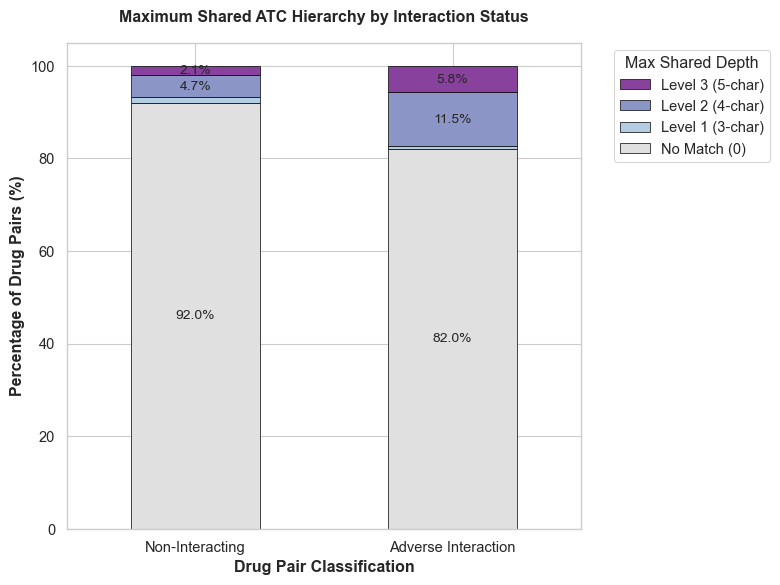

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ==========================================
# 1. HELPER: EXTRACT MAX SHARED DEPTH
# ==========================================
def get_max_shared_depth(atc_list_a, atc_list_b):
    """
    Evaluates two lists of ATC codes and returns the deepest hierarchical
    level they share.
    Returns:
      3: Share Level 3 (5-char, Chemical/therapeutic subgroup)
      2: Share Level 2 (4-char, Pharmacological subgroup)
      1: Share Level 1 (3-char, Therapeutic main group)
      0: No shared ancestry
    """
    if not isinstance(atc_list_a, (list, tuple, np.ndarray)) or not isinstance(atc_list_b, (list, tuple, np.ndarray)):
        return 0

    level_3_a, level_2_a, level_1_a = set(), set(), set()
    for code in atc_list_a:
        if isinstance(code, str) and len(code.strip()) >= 3:
            code = code.strip().upper()
            level_1_a.add(code[:3])
            if len(code) >= 4:
                level_2_a.add(code[:4])
            if len(code) >= 5:
                level_3_a.add(code[:5])

    level_3_b, level_2_b, level_1_b = set(), set(), set()
    for code in atc_list_b:
        if isinstance(code, str) and len(code.strip()) >= 3:
            code = code.strip().upper()
            level_1_b.add(code[:3])
            if len(code) >= 4:
                level_2_b.add(code[:4])
            if len(code) >= 5:
                level_3_b.add(code[:5])

    if level_3_a.intersection(level_3_b):
        return 3
    if level_2_a.intersection(level_2_b):
        return 2
    if level_1_a.intersection(level_1_b):
        return 1
    return 0


# ==========================================
# 2. BUILD ANALYSIS DATAFRAME FROM REAL NOTEBOOK DATA
# ==========================================
analysis_df = pd.concat(
    [
        adverse_pairs_similarity_df.assign(is_adverse_interaction=1),
        non_interacting_pairs_similarity_df.assign(is_adverse_interaction=0),
    ],
    ignore_index=True,
)

# Parse ATC lists from the notebook dataframes.
# The notebook stores them as strings, so we split them into Python lists.
def parse_atc_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, str):
        return [item.strip().upper() for item in value.replace(";", ",").split(",") if item.strip()]
    if isinstance(value, (list, tuple, np.ndarray)):
        return [str(item).strip().upper() for item in value if str(item).strip()]
    return []

analysis_df["atc_list_1"] = analysis_df["atc_codes_list_1"].apply(parse_atc_list)
analysis_df["atc_list_2"] = analysis_df["atc_codes_list_2"].apply(parse_atc_list)

analysis_df["max_shared_depth"] = analysis_df.apply(
    lambda row: get_max_shared_depth(row["atc_list_1"], row["atc_list_2"]),
    axis=1,
)

# ==========================================
# 3. CROSS-TABULATION & PERCENTAGES
# ==========================================
contingency_table = pd.crosstab(
    analysis_df["is_adverse_interaction"],
    analysis_df["max_shared_depth"],
    rownames=["Adverse Interaction"],
    colnames=["Max Shared Depth"],
)

percentage_table = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("--- PERCENTAGE OF PAIRS BY MAX SHARED DEPTH ---")
print_df = percentage_table.rename(
    index={0: "Non-Interacting (0)", 1: "Interacting (1)"},
    columns={0: "None", 1: "Level 1 (3-char)", 2: "Level 2 (4-char)", 3: "Level 3 (5-char)"},
).round(2)
print(print_df.to_string())
print("\n")

# ==========================================
# 4. CHI-SQUARE TEST OF INDEPENDENCE
# ==========================================
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("--- STATISTICAL SIGNIFICANCE (CHI-SQUARE) ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.20e}")
if p_value < 0.05:
    print("Conclusion: The depth of shared ATC ancestry is significantly dependent on whether the drug pair has an adverse interaction.")

# ==========================================
# 5. VISUALIZATION: 100% STACKED BAR CHART
# ==========================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#e0e0e0", "#b3cde3", "#8c96c6", "#88419d"]
labels = ["No Match (0)", "Level 1 (3-char)", "Level 2 (4-char)", "Level 3 (5-char)"]

percentage_table.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title("Maximum Shared ATC Hierarchy by Interaction Status", fontweight="bold", pad=15)
ax.set_xlabel("Drug Pair Classification", fontweight="bold")
ax.set_ylabel("Percentage of Drug Pairs (%)", fontweight="bold")
ax.set_xticklabels(["Non-Interacting", "Adverse Interaction"], rotation=0)

handles, _ = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), title="Max Shared Depth", bbox_to_anchor=(1.05, 1), loc="upper left")

for c in ax.containers:
    labels_text = [f"{v.get_height():.1f}%" if v.get_height() > 2 else "" for v in c]
    ax.bar_label(c, labels=labels_text, label_type="center", fontsize=10)

plt.tight_layout()
plt.show()